In [31]:
import pandas as pd
import warnings
warnings.filterwarnings('ignore')


df_users = pd.read_parquet('../users_info.parquet')
df_horses = pd.read_parquet('../horses_listings_limpio.parquet')
df_sessions_horses = pd.read_parquet('../horses_sessions_info.parquet')
df_prods = pd.read_parquet('../products_listing_limpio.parquet')
df_sessions_prods = pd.read_parquet('../prods_sessions_info.parquet')

# Limpiamos los nombres de columnas para que no nos den errores de mayúsculas
for df in [df_users, df_horses, df_sessions_horses, df_prods, df_sessions_prods]:
    df.columns = [c.lower().strip() for c in df.columns]

print("✅ Paso 1: Datos cargados y limpios.")

✅ Paso 1: Datos cargados y limpios.


In [23]:
# Unimos sesiones con catálogo de caballos
df_int_horses = pd.merge(df_sessions_horses, df_horses[['horse_id', 'price']], on='horse_id')
# Sacamos el promedio por usuario
perfil_horses = df_int_horses.groupby('user_id')['price'].mean().reset_index()
perfil_horses.columns = ['user_id', 'gasto_caballos']

print("✅ Paso 2: Perfil de interés en caballos listo.")

✅ Paso 2: Perfil de interés en caballos listo.


In [27]:

# 1. Unimos usando 'item_id'
df_int_prods = pd.merge(df_sessions_prods, df_prods[['item_id', 'price']], on='item_id')

# 2. Limpieza de precio 
df_int_prods['price'] = pd.to_numeric(df_int_prods['price'], errors='coerce').fillna(0)

# 3. Sacamos el promedio por usuario
perfil_prods = df_int_prods.groupby('user_id')['price'].mean().reset_index()

# 4. Renombramos para que el Gran Merge final sea fácil de entender
perfil_prods.columns = ['user_id', 'gasto_productos']

print("✅ Paso 3: ¡Conseguido! ")
display(perfil_prods.head())

✅ Paso 3: ¡Conseguido! 


,user_id,gasto_productos
0,00000e91-95ca-46fd-b648-7bb64c36cd6f,690.000
1,00003194-e0c4-46a4-a410-0c9a4740dd83,1099.950
2,0000e014-2982-409b-a03d-447ff45f2713,912.618
3,0001663c-05ac-4d4c-9634-0b5dc5c0f4e5,612.385
4,0001ba95-dea4-4509-9c78-bb71045be16e,792.500


In [28]:
# Juntamos usuarios + info de caballos + info de productos
df_final = pd.merge(df_users, perfil_horses, on='user_id', how='left')
df_final = pd.merge(df_final, perfil_prods, on='user_id', how='left')

# Definimos la Segmentación Final
def segmentar(row):
    if row['gasto_caballos'] > 50000:
        return 'Oro'
    elif row['gasto_caballos'] > 0 or row['gasto_productos'] > 500:
        return 'Plata'
    else:
        return 'Bronce'

df_final['target_lead'] = df_final.apply(segmentar, axis=1)

print("🏆 ¡SEGMENTACIÓN TOTAL COMPLETADA!")
print(df_final['target_lead'].value_counts())

🏆 ¡SEGMENTACIÓN TOTAL COMPLETADA!
target_lead
Plata     187453
Bronce      6634
Oro         5913
Name: count, dtype: int64


In [29]:
# 1. Definimos el nombre del archivo 
#nombre_archivo = '../users_with_target_v2_completo.parquet'

# 2. Guardamos el DataFrame que acabamos de terminar
#df_final.to_parquet(nombre_archivo)

#print(f"✅ ¡Archivo creado con éxito!: {nombre_archivo}")
#print(f"📊 Total de registros guardados: {len(df_final)}")

✅ ¡Archivo creado con éxito!: ../users_with_target_v2_completo.parquet
📊 Total de registros guardados: 200000


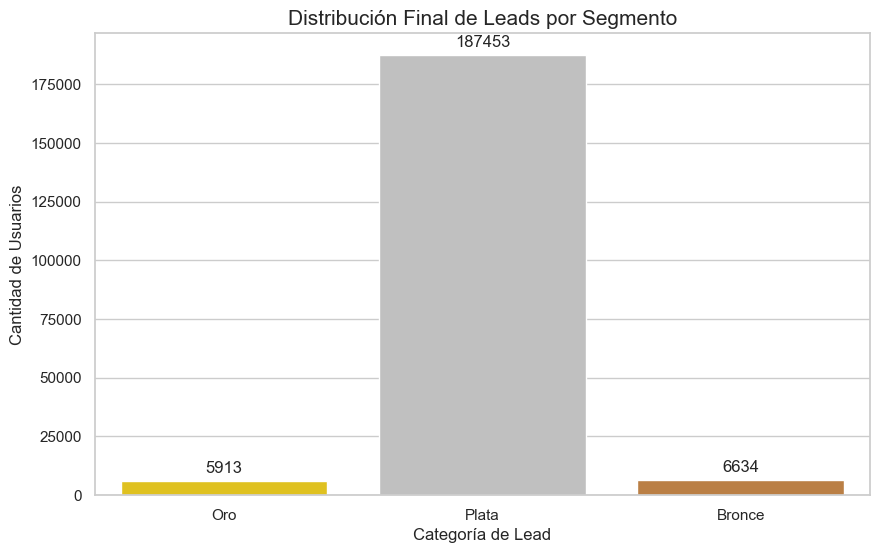

In [32]:
import matplotlib.pyplot as plt
import seaborn as sns

#estilo
plt.figure(figsize=(10, 6))
sns.set_theme(style="whitegrid")

# gráfico de barras
ax = sns.countplot(x='target_lead', data=df_final, palette={'Oro': '#FFD700', 'Plata': '#C0C0C0', 'Bronce': '#CD7F32'}, order=['Oro', 'Plata', 'Bronce'])

#títulos y etiquetas
plt.title('Distribución Final de Leads por Segmento', fontsize=15)
plt.xlabel('Categoría de Lead', fontsize=12)
plt.ylabel('Cantidad de Usuarios', fontsize=12)

# Añadimos los números sobre las barras
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha = 'center', va = 'center', xytext = (0, 9), textcoords = 'offset points')

plt.show()

In [37]:
import ast

# 1. Función para extraer solo el título (title) del diccionario
def extraer_titulo(dato):
    try:
        # Si el dato es un string que parece diccionario, lo convertimos
        if isinstance(dato, str):
            dato = ast.literal_eval(dato)
        return dato.get('title', 'No especificado')
    except:
        return 'No especificado'

# 2. Aplicamos la limpieza a todo el DataFrame final
df_final['job_title'] = df_final['job_info'].apply(extraer_titulo)

# 3. veamos el Top 10 limpio

print("🌍 Top 10 Países con más clientes ORO:")
print(df_final[df_final['target_lead'] == 'Oro']['country'].value_counts().head(10))

print("\n\n💼 Top 10 Profesiones en el segmento ORO (Limpio):")
print(df_final[df_final['target_lead'] == 'Oro']['job_title'].value_counts().head(10))

🌍 Top 10 Países con más clientes ORO:
country
India          356
Nigeria        198
Indonesia      187
Switzerland    187
Luxembourg     161
Israel         157
Belgium        140
Ireland        133
Canada         127
Bahrain         90
Name: count, dtype: int64


💼 Top 10 Profesiones en el segmento ORO (Limpio):
job_title
Stable owner                     84
Equestrian brand founder         83
Professional show jumper         80
Sport horse vet                  78
Luxury horse owner               76
Equestrian investment advisor    76
Equine sports veterinarian       74
Thoroughbred breeder             74
Horse sales agent                73
Equestrian center director       73
Name: count, dtype: int64
